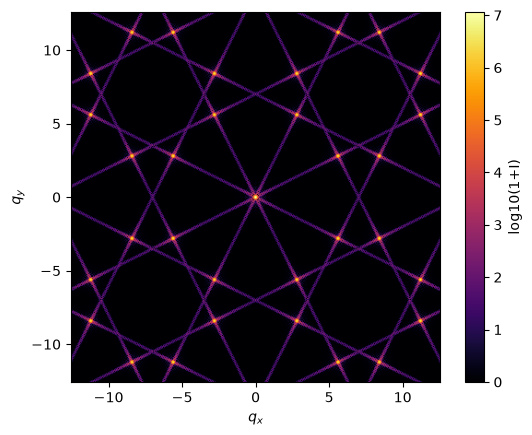

In [4]:
import numpy as np, matplotlib.pyplot as plt

m = 2; r = np.arctan(1/m); N = 30            # tan r = 1/m ; patch half-width
n = np.arange(-N, N+1); X, Y = np.meshgrid(n, n)
P = np.c_[X.ravel(), Y.ravel()].astype(float)
def rot(a): return np.array([[np.cos(a), -np.sin(a)], [np.sin(a), np.cos(a)]])
pts = np.vstack([P @ rot(-r).T, P @ rot(+r).T])       # both layers, in-plane coords

# w = np.exp(-(pts**2).sum(1) / (2*(0.6*N)**2))         # Gaussian window: suppresses edge ripples
w = np.exp(-(pts**2).sum(1) / (2*(0.60*N)**2))   # sigma = 7: weight at edge ≈ 0.017
q = np.linspace(-4*np.pi, 4*np.pi, 401); QX, QY = np.meshgrid(q, q)
I = np.zeros_like(QX)
for a in range(QX.shape[0]):                          # row by row keeps memory small
    ph = np.exp(-1j*(np.outer(QX[a], pts[:, 0]) + np.outer(QY[a], pts[:, 1])))
    I[a] = np.abs(ph @ w)**2

plt.imshow(np.log10(I + 1), extent=[-4*np.pi, 4*np.pi]*2, origin="lower", cmap="inferno")
plt.xlabel("$q_x$"); plt.ylabel("$q_y$"); plt.colorbar(label="log10(1+I)")
plt.savefig("diffraction_m2.png", dpi=150)